Starting test: Finding solutions for the first 24 robots...

--- Test Completed ---
Total Stations Built: 2 | Total Cost: £2252.98


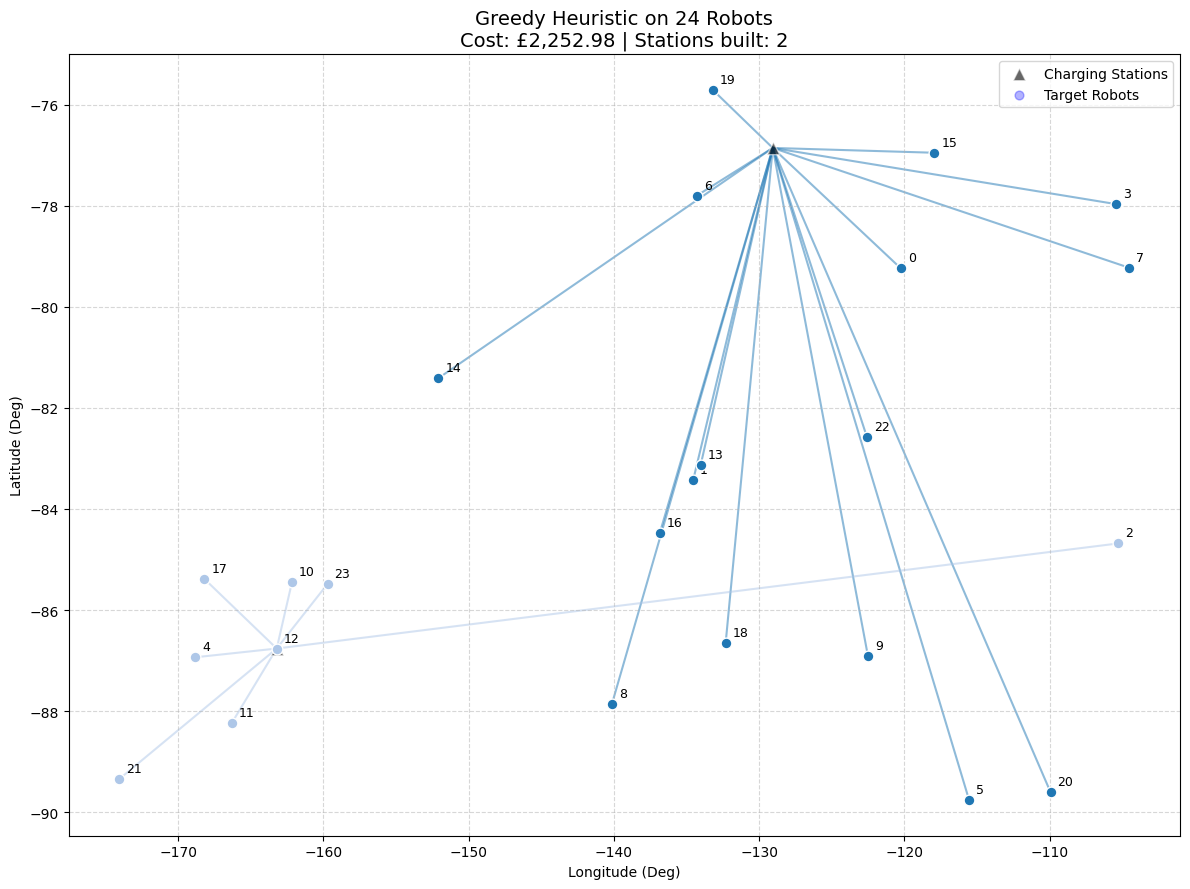

In [1]:
# 24 robots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================================================
# 1. Data Loading and Preprocessing
# =========================================================
df_loc = pd.read_csv('robot_locations.csv')
df_range = pd.read_csv('range.csv')

# Extract coordinates and ranges
coords = df_loc[['longitude', 'latitude']].values
ranges = df_range['range'].values
N = len(coords)

# =========================================================
# 2. Distance Matrix Calculation 
# (Removed 111.111 conversion, using Euclidean distance directly)
# =========================================================
diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# =========================================================
# 3. Cost Parameters
# =========================================================
C_b = 5000                
C_m = 500                 
C_b_daily = C_b / 365.0   # Daily station construction cost (approx £13.70)
C_m_daily = C_m / 365.0   # Daily maintenance cost (approx £1.37)
C_c = 0.42                
C_h = 1000                
MAX_ROBOTS = 16           
R_MAX = 175 * 1.60934     # ★ r_max (aligned with 1(a) value 281.63)

# =========================================================
# 4. Greedy Heuristic (Testing on the first 24 robots)
# =========================================================
SUBSET_SIZE = 24  

unassigned = set(range(SUBSET_SIZE))
candidates = set(range(N))

stations_built = []     
total_cost = 0

print(f"Starting test: Finding solutions for the first {SUBSET_SIZE} robots...")

start_time = time.time()
iteration = 0

while unassigned:
    best_savings = 0
    best_candidate = None
    best_subset = []
    best_cost_serve = 0
    
    for j in candidates:
        reachable = []
        for i in unassigned:
            if dist_matrix[i, j] <= ranges[i]:
                reachable.append(i)
                
        if not reachable: continue
            
        reachable.sort(key=lambda i: dist_matrix[i, j])
        subset = reachable[:MAX_ROBOTS]
        n_served = len(subset)
        
        cost_penalty = n_served * C_h
        chargers_needed = math.ceil(n_served / 2)
        
        # ★ C3: (R_MAX - self_range + flight_distance) * 0.42
        cost_flying = sum((R_MAX - ranges[i] + dist_matrix[i, j]) * C_c for i in subset)
        
        cost_serve = C_b_daily + (chargers_needed * C_m_daily) + cost_flying
        savings = cost_penalty - cost_serve
        
        if savings > best_savings:
            best_savings = savings
            best_candidate = j
            best_subset = subset
            best_cost_serve = cost_serve
            
    if best_savings > 0:
        iteration += 1
        stations_built.append((best_candidate, best_subset))
        total_cost += best_cost_serve
        candidates.remove(best_candidate)
        for robot in best_subset: unassigned.remove(robot)
    else:
        break

unassigned_cost = len(unassigned) * C_h
total_cost += unassigned_cost

print(f"\n--- Test Completed ---")
print(f"Total Stations Built: {len(stations_built)} | Total Cost: £{total_cost:.2f}")

# =========================================================
# 5. Visualization
# =========================================================
fig, ax = plt.subplots(figsize=(12, 9))

# ID Labels
for i in range(SUBSET_SIZE):
    ax.annotate(str(i), (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Draw red 'x' markers for robots incurring a penalty (unassigned)
unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=100, linewidth=2, label='Unassigned (Penalty)', zorder=3)

station_coords_x, station_coords_y = [], []
cmap = plt.get_cmap('tab20') 

# Draw charging stations and connection lines
for idx, (stat_id, robots) in enumerate(stations_built):
    color = cmap(idx % 20)
    sx, sy = coords[stat_id]
    station_coords_x.append(sx); station_coords_y.append(sy)
    
    for r_id in robots:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.5, linewidth=1.5, zorder=1)
        ax.scatter(rx, ry, c=[color], s=60, edgecolors='white', zorder=5)

# Draw charging station icons (triangles)
if station_coords_x:
    ax.scatter(station_coords_x, station_coords_y, c='black', marker='^', s=80, alpha=0.6, edgecolors='white', zorder=4, label='Charging Stations')

# Draw underlying target robots
ax.scatter(coords[:SUBSET_SIZE, 0], coords[:SUBSET_SIZE, 1], c='blue', s=40, alpha=0.3, label='Target Robots', zorder=2)

ax.set_title(f'Greedy Heuristic on {SUBSET_SIZE} Robots\nCost: £{total_cost:,.2f} | Stations built: {len(stations_built)}', fontsize=14)
ax.set_xlabel('Longitude (Deg)'); ax.set_ylabel('Latitude (Deg)')
ax.legend(loc='best'); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()